In [ ]:
#Run CSWAP
using QuantumOptics
using Plots

b_spin = SpinBasis(1//2)

const sx = sigmax(b_spin)
const sy = sigmay(b_spin)
const sz = sigmaz(b_spin)
const sp = (sx + 1im*sy)/2
const sm = (sx - 1im*sy)/2

const up = spinup(b_spin)
const down = spindown(b_spin)
const I_s = identityoperator(b_spin)


function Rn_id(psi, theta, sn, id)
    if id == 0
        return exp(-1im * theta/2 * tensor(sn, I_s, I_s))*psi
    elseif id == 1
        return exp(-1im * theta/2 * tensor(I_s, sn, I_s))*psi
    elseif id == 2
        return exp(-1im * theta/2 * tensor(I_s, I_s, sn))*psi
    end
end

function Rxx(psi, theta, id1, id2)
    if id1 == 0 && id2 == 1
        psi = exp(-1im * theta/2 * tensor(sx, sx, I_s))*psi
    elseif id1 == 0 && id2 == 2
        psi = exp(-1im * theta/2 * tensor(sx, I_s, sx))*psi
    elseif id1 == 1 && id2 == 2
        psi = exp(-1im * theta/2 * tensor(I_s, sx, sx))*psi
    end
    return psi
end

function cswap(psi)
    # decompose CSWAP into Rn and Rxx gates using Tenzan's method
    psi = Rn_id(psi, 7*pi/2, sy, 0)
    psi = Rn_id(psi, 7*pi/2, sz, 1)
    psi = Rxx(psi, 5*pi/2, 1, 2)
    psi = Rn_id(psi, 7*pi/4, sz, 1)
    psi = Rn_id(psi, 3*pi/4, sz, 2)
    psi = Rn_id(psi, pi/2, sy, 1)
    psi = Rxx(psi, 7*pi/2, 0, 2)
    psi = Rn_id(psi, 11*pi/4, sy, 2)
    psi = Rxx(psi, 7*pi/2, 1, 2)
    psi = Rxx(psi, pi/4, 0, 1)a
    psi = Rn_id(psi, pi/4, sz, 2)
    psi = Rxx(psi, 5*pi/2, 0, 2)
    psi = Rn_id(psi, 5*pi/2, sy, 0)
    psi = Rn_id(psi, 5*pi/2, sz, 1)
    psi = Rn_id(psi, 7*pi/4, sy, 2)
    psi = Rxx(psi, 7*pi/2, 1, 2)
    psi = Rn_id(psi, pi/2, sy, 1)
    psi = Rn_id(psi, 11*pi/4, sz, 0)
    return psi
end

function cswap_wrap(psi)
    # decompose CSWAP into Rn and Rxx gates using Tenzan's method, but with phases wrapped
    psi = Rn_id(psi, -pi/2, sy, 0) # wrap phase to -pi/2
    psi = Rn_id(psi, -pi/2, sz, 1) # wrap phase to -pi/2
    psi = Rxx(psi, pi/2, 1, 2) # Global phase ignored
    psi = Rn_id(psi, -pi/4, sz, 1) # wrap phase to -pi/4
    psi = Rn_id(psi, pi/2, sy, 1)
    psi = Rn_id(psi, -pi/4, sz, 2) # Z sandwich and combine with prev.
    psi = Rxx(psi, pi/2, 0, 2) # wrap phase to pi/2 and sandwich with Z
    psi = Rn_id(psi, pi, sz, 2) # Z sandwich

    psi = Rn_id(psi, 3*pi/4, sy, 2) # wrap phase to 3*pi/4

    psi = Rn_id(psi, pi, sz, 2) # Z sandwich
    psi = Rxx(psi, pi/2, 1, 2) # wrap phase to pi/2 and sandwich with Z
    psi = Rn_id(psi, pi, sz, 2) # Z sandwich

    psi = Rxx(psi, pi/4, 0, 1)
    psi = Rn_id(psi, pi/4, sz, 2)
    psi = Rxx(psi, pi/2, 0, 2) # Global phase ignored
    psi = Rn_id(psi, pi/2, sy, 0) # Global phase ignored
    psi = Rn_id(psi, pi/2, sz, 1) # Global phase ignored
    psi = Rn_id(psi, -pi/4, sy, 2) # wrap phase to -pi/4

    psi = Rn_id(psi, pi, sz, 2) # Z sandwich
    psi = Rxx(psi, pi/2, 1, 2) # wrap phase to pi/2 and sandwich with Z
    psi = Rn_id(psi, pi, sz, 2) # Z sandwich

    psi = Rn_id(psi, pi/2, sy, 1)
    psi = Rn_id(psi, 3*pi/4, sz, 0) # wrap phase to 3*pi/4
    return psi
end

function measure1(psi, id)
    if id == 0
        rho = ptrace(psi, [2,3])
    elseif id == 1
        rho = ptrace(psi, [1,3])
    elseif id == 2
        rho = ptrace(psi, [1,2])
    end
    p_up = real(expect(projector(up), rho))
    p_down = real(expect(projector(down), rho))
    return p_up, p_down
end

measure1 (generic function with 1 method)

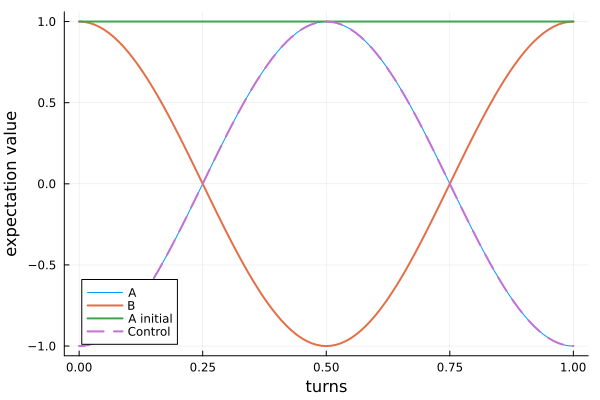

In [ ]:
psi_0 = tensor(down, up, down)
turns_list = collect(0:0.01:1)
c_list = []
a_list = []
b_list = []
i_list = []

for turns in turns_list
    # Create initial state
    psi = Rn_id(psi_0, turns*2pi, sx, 0)

    # Apply the CSWAP gate
    psi_swapped = cswap_wrap(psi)

    # # Measure the state in the computational basis
    c_u, c_d = measure1(psi_swapped, 0)
    a_u, a_d = measure1(psi_swapped, 1)
    b_u, b_d = measure1(psi_swapped, 2)
    i_u, i_d = measure1(psi_0, 1)
    push!(c_list, c_u - c_d)
    push!(a_list, a_u - a_d)
    push!(b_list, b_u - b_d)
    push!(i_list, i_u - i_d)
end

plot(turns_list, a_list, label="A", xlabel="turns", ylabel="expectation value")
plot!(turns_list, b_list, label="B", linewidth=2)
plot!(turns_list, i_list, label="A initial", linewidth=2)
plot!(turns_list, c_list, label="Control", line=:dash, linewidth=2)